# IPrint News Recommendation Ranking Systems

## Data Cleaning

In [68]:
# Suppress non-critical warnings so the EDA output remains clean.
# Useful in notebooks where repeated pandas/sklearn warnings can make the analysis difficult to read.
import warnings
warnings.filterwarnings("ignore")

In [69]:
#  NumPy: Used for numerical operations, arrays, mathematical functions, popularity calculations, sparsity calculations, etc.
import numpy as np

# Pandas: Main library for loading, cleaning, transforming and analyzing consumer interaction and platform-content datasets.
import pandas as pd

# Matplotlib: Used to create EDA visualizations such as user activity distributions, article popularity, temporal trends, session behavior
import matplotlib.pyplot as plt

#  Seaborn : Provides higher-level statistical visualizations.
import seaborn as sns

In [70]:
# Path: Provides safer and cleaner filesystem path handling
from pathlib import Path

In [71]:
# Load user-consumer interaction events
consumer = pd.read_csv("D:\iPrint-News-Recommendation-Ranking-System\Dataset\consumer_transanctions.csv")

In [72]:
# Load platform content metadata.
content = pd.read_csv("D:\iPrint-News-Recommendation-Ranking-System\Dataset\platform_content.csv")

In [73]:
# Display the number of rows and columns in each dataset.
print("Consumer transactions:", consumer.shape)
print("Platform content:", content.shape)

Consumer transactions: (72312, 8)
Platform content: (3122, 13)


## 1. Mising Values Analysis

- Generate a data-quality report containing: Number of missing values, Percentage of missing values, Number of unique values

- This helps determine which features require: imputation, unknown-category handling, removal special treatment

In [74]:
# missing values analysis
def missing_report(df):
    report = pd.DataFrame({

        # total number of missing observation
        "missing_count": df.isna().sum(),

        # percentage of records that are missing
        "missing_percentage": (
            df.isna().mean() * 100
        ).round(2),

        # number of unique non-null values
        "unique_values": df.nunique()
    })

    # sort features by missing percentange so the most problematic column appear first
    return report.sort_values("missing_percentage",ascending=False)

In [75]:
#  Analyze missing values in user interaction data.
print("Consumer Data", consumer.shape)
display(missing_report(consumer))

Consumer Data (72312, 8)


,missing_count,missing_percentage,unique_values
consumer_location,15405,21.30,71
consumer_device_info,15394,21.29,1090
country,15394,21.29,23
event_timestamp,0,0.00,68772
interaction_type,0,0.00,5
item_id,0,0.00,2987
consumer_id,0,0.00,1895
consumer_session_id,0,0.00,28909


In [76]:
# Analyze missing values in article/content metadata.
print("Platform Content")
display(missing_report(content))

Platform Content


,missing_count,missing_percentage,unique_values
producer_device_info,2442,78.22,114
producer_location,2442,78.22,19
producer_country,2442,78.22,5
event_timestamp,0,0.00,3121
interaction_type,0,0.00,2
item_id,0,0.00,3057
producer_id,0,0.00,252
producer_session_id,0,0.00,2017
item_type,0,0.00,3
item_url,0,0.00,3029


## 2. Duplicates Analysis

- Check whether the same complete interaction record appears more than once
- extact duplicates may represent duplicates ingestion, repeated data loading, pipeline errors

In [77]:
print("Exact duplicate consumer rows:")
print(consumer.duplicated().sum())
print("Exact duplicate content rows:")
print(content.duplicated().sum())

Exact duplicate consumer rows:
11
Exact duplicate content rows:
0


## 3. Repreated User Article Interactions

- A user may interact with the same article multiple times.
- measure repeated user-item interactions to understand hether interaction frequency contains useful behavioral signal.

In [78]:
user_item_duplicates = consumer.duplicated(subset=["consumer_id", "item_id"]).sum()

In [18]:
print("Repeated consumer-item interactions:",user_item_duplicates)

Repeated consumer-item interactions: 31602


In [19]:
print("Repeated interaction percentage:",round(user_item_duplicates / len(consumer) * 100,2),"%")

Repeated interaction percentage: 43.7 %


## 4. Repeated user + item + interaction type

- measures cases where the same user performed the same type of interaction with the same article multiple times this help repeated consumption from different types of engagements
- help determine whether : frequency + interaction type

In [80]:
user_item_type_duplicates = consumer.duplicated(subset=["consumer_id","item_id","interaction_type"]).sum()

In [81]:
print("Repeated user-item-interaction events:", user_item_type_duplicates)

Repeated user-item-interaction events: 21374


## 5. Interaction Intensity Per User

- Identifies : Power users, Casual users, Low-activity users, Cold-start users

In [22]:
user_activity = (consumer.groupby("consumer_id").agg(
    total_interactions=("item_id", "size"),
    unique_articles=("item_id", "nunique"),
    unique_sessions=("consumer_session_id", "nunique")).sort_values(
    "total_interactions",ascending=False))

display(user_activity.describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

,total_interactions,unique_articles,unique_sessions
count,1895.000000,1895.000000,1895.000000
mean,38.159367,21.482850,15.255409
std,104.143355,52.307036,23.729428
min,1.000000,1.000000,1.000000
50%,10.000000,6.000000,6.000000
75%,32.000000,19.000000,18.000000
90%,88.000000,46.000000,40.000000
95%,155.600000,86.000000,59.000000
99%,458.160000,257.240000,113.120000
max,1885.000000,961.000000,232.000000


## 6. User distribution plots

- Distribution of unique articles consumed by each user.
- Useful for understanding the breadth of user interests.

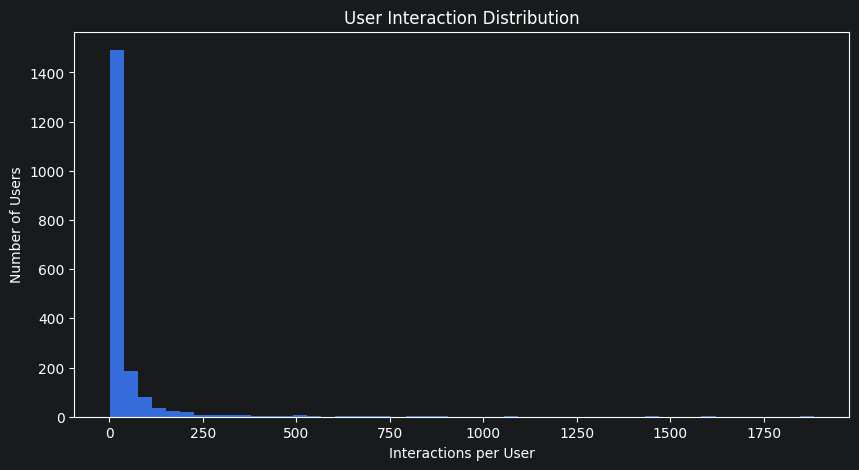

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity["total_interactions"],bins=50)
plt.xlabel("Interactions per User")
plt.ylabel("Number of Users")
plt.title("User Interaction Distribution")
plt.show()

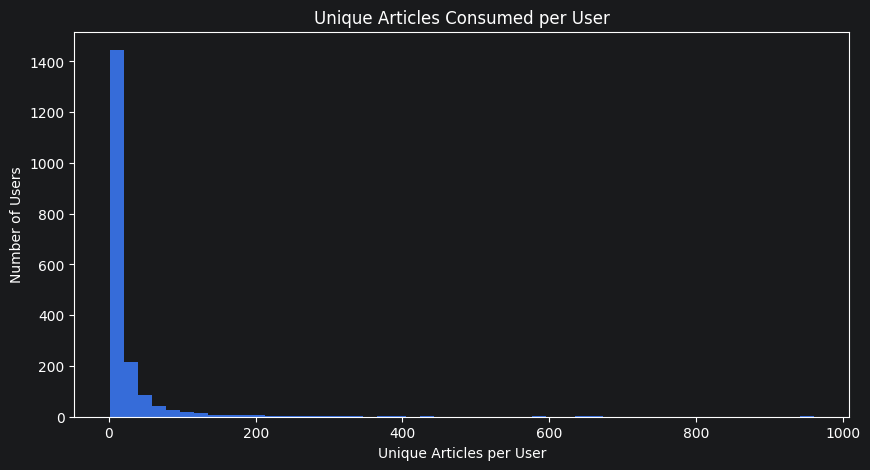

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity["unique_articles"], bins=50)
plt.xlabel("Unique Articles per User")
plt.ylabel("Number of Users")
plt.title("Unique Articles Consumed per User")
plt.show()

## 7. Article Popularity Distribution

- Calculate article-level engagement.
- total_interactions: How many interaction events an article received.
- unique_users: How many different users interacted with the article.

In [25]:
article_popularity = (consumer.groupby("item_id").agg(total_interactions=("consumer_id", "size"),
                                                      unique_users=("consumer_id", "nunique")).sort_values("total_interactions",ascending=False))
display(article_popularity.describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

,total_interactions,unique_users
count,2987.000000,2987.000000
mean,24.208905,13.629059
std,32.448298,17.151984
min,1.000000,1.000000
50%,14.000000,9.000000
75%,30.000000,17.000000
90%,54.000000,30.000000
95%,80.000000,43.000000
99%,161.560000,79.280000
max,433.000000,268.000000


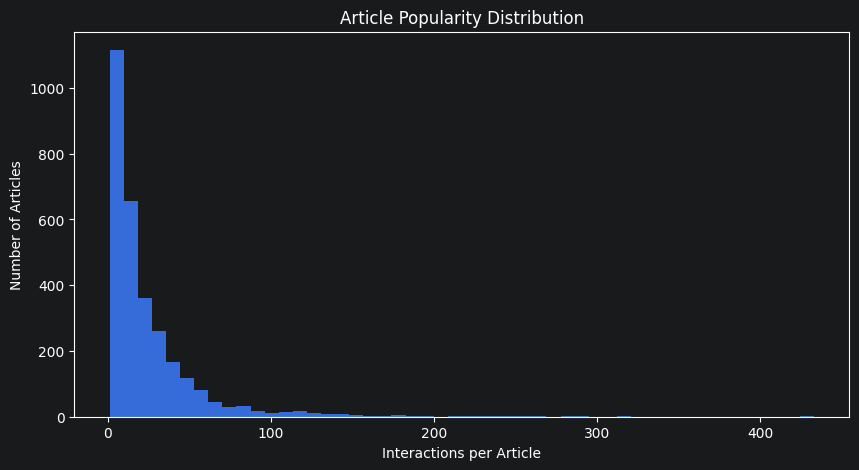

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(article_popularity["total_interactions"],bins=50)
plt.xlabel("Interactions per Article")
plt.ylabel("Number of Articles")
plt.title("Article Popularity Distribution")
plt.show()

## 8. Long Tail Analysis

- Measure how much interaction comes from the most popular articles
- Supports the business argument : Popularity-only recommendation, Low perronalization, Poor discovery, Need personalized ranking

In [27]:
# Sort articles from most to least interacted-with.
popularity = (article_popularity["total_interactions"].sort_values(ascending=False).reset_index(drop=True))

# Total number of interaction events.
total_interactions = popularity.sum()

# Measure how much engagement is concentrated in the top-K articles.
for k in [1, 5, 10, 20, 50, 100]:
    top_k_interactions = popularity.head(k).sum()
    percentage = (top_k_interactions / total_interactions * 100)
    print("Top {k} articles account for  {percentage:.2f}% of interactions")

Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions
Top {k} articles account for  {percentage:.2f}% of interactions


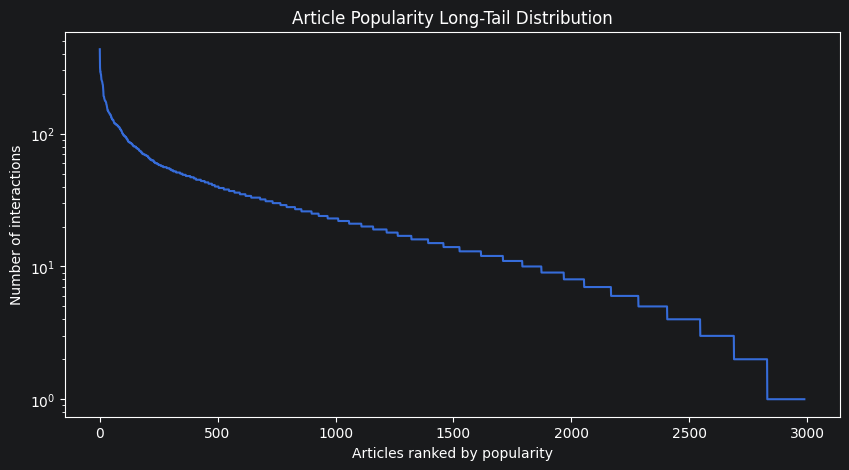

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(popularity) + 1),popularity.values)
plt.xlabel("Articles ranked by popularity")
plt.ylabel("Number of interactions")
plt.title("Article Popularity Long-Tail Distribution")
plt.yscale("log")
plt.show()

## 9. User * items Sparsity

- currently create user item matrix
- justifies using ALS, Implicit CF, Matrix Factorization, Content Based Fallback rather than dense superived model over every user article combination

In [29]:
n_users = consumer["consumer_id"].nunique()
n_items = consumer["item_id"].nunique()
unique_user_item_pairs = (consumer[["consumer_id", "item_id"]].drop_duplicates().shape[0])
possible_interactions = n_users * n_items
density = (unique_user_item_pairs / possible_interactions)
sparsity = 1 - density
print("Users:", n_users)
print("Items:", n_items)
print("Possible user-item pairs:", possible_interactions)
print("Observed user-item pairs:", unique_user_item_pairs)
print(f"Density: {density:.6f}")
print(f"Sparsity: {sparsity:.6%}")

Users: 1895
Items: 2987
Possible user-item pairs: 5660365
Observed user-item pairs: 40710
Density: 0.007192
Sparsity: 99.280788%


## 10. Cold Start Analysis

- New articles don't have enough interaction history for collaborative filtering.
- Therefore system needs a fallback : New Article ->  Title + Description -> SBERT -> FAISS -> Content-based recommendation

In [30]:
user_counts = (consumer.groupby("consumer_id").size())
print("Users with exactly 1 interaction:")
print((user_counts == 1).sum())
print("Users with <= 3 interactions:")
print((user_counts <= 3).sum())
print("Users with <= 5 interactions:")
print((user_counts <= 5).sum())

Users with exactly 1 interaction:
180
Users with <= 3 interactions:
482
Users with <= 5 interactions:
675


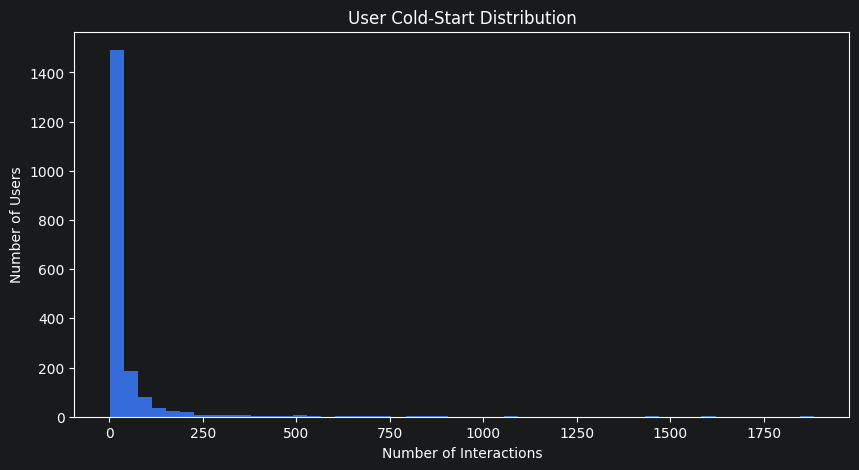

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(user_counts,bins=50)
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.title("User Cold-Start Distribution")
plt.show()

## 11. Article cold-start

- New articles don't have enough interaction history for collaborative filtering.
- Therefore: New Article -> Title + Description -> SBERT -> FAISS -> Content-based recommendation

In [32]:
item_counts = (consumer.groupby("item_id").size())
print("Articles with exactly 1 interaction:")
print((item_counts == 1).sum())
print("Articles with <= 3 interactions:")
print((item_counts <= 3).sum())
print("Articles with <= 5 interactions:")
print((item_counts <= 5).sum())

Articles with exactly 1 interaction:
158
Articles with <= 3 interactions:
442
Articles with <= 5 interactions:
704


## 12. Temporal Feature Analysis

- Convert Unix timestamps into timezone-aware datetime values.
- event_datetime in consumer:  Time when the USER interacted with an article.
- event_datetime in content: Time associated with the CONTENT lifecycle/event.
- News is time-sensitive so recommendation model trained randomly can accidentally use future behavior to predict past behavior Therefore final model should use: Temporal Train -> Temporal Validation -> Temporal Test rather than random splitting

In [33]:
consumer["event_datetime"] = pd.to_datetime(consumer["event_timestamp"],unit="s",utc=True)
content["event_datetime"] = pd.to_datetime(content["event_timestamp"],unit="s",utc=True)
print("Consumer interaction period:",consumer["event_datetime"].min(),"→",consumer["event_datetime"].max())
print("Content event period:",content["event_datetime"].min(),"→",content["event_datetime"].max())

Consumer interaction period: 2016-03-14 13:54:36+00:00 → 2017-02-28 19:21:51+00:00
Content event period: 2016-03-28 19:19:39+00:00 → 2017-02-28 18:51:11+00:00


## 13. Daliy Interaction Tread

- Resample interaction events into daily totals.

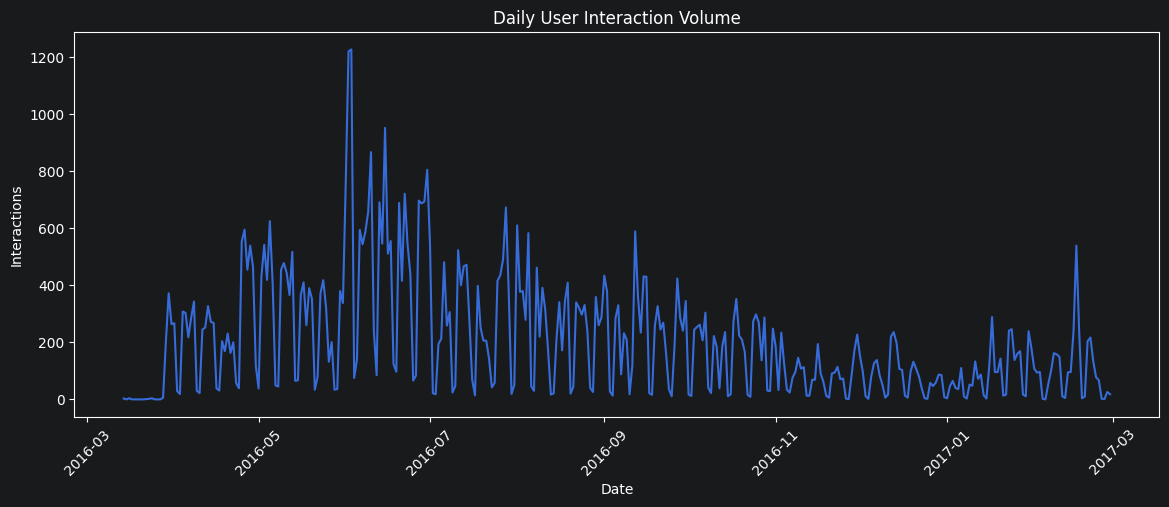

In [34]:
daily_interactions = (consumer.set_index("event_datetime").resample("D").size())
plt.figure(figsize=(14, 5))
plt.plot(daily_interactions.index,daily_interactions.values)
plt.xlabel("Date")
plt.ylabel("Interactions")
plt.title("Daily User Interaction Volume")
plt.xticks(rotation=45)
plt.show()

## 14. Hour Of Days Behaviours

- Extract the hour at which each user interaction occurred
- Later can create: is_morning, is_afternoon, is_evening and use them as contextual ranking features

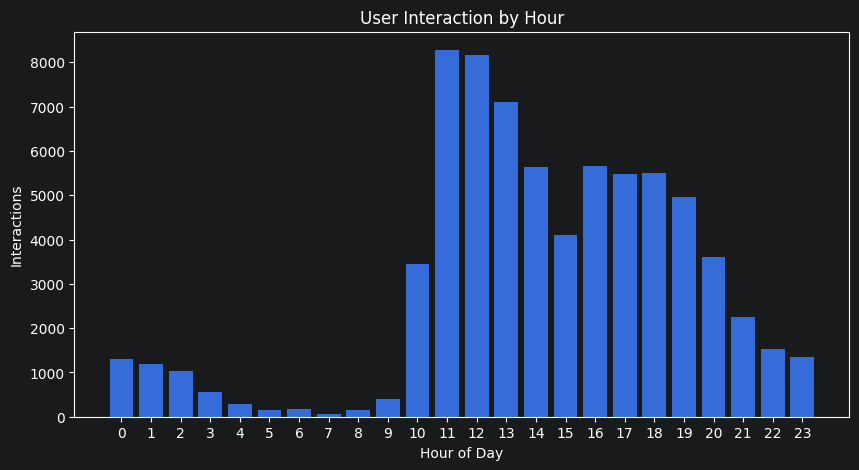

In [35]:
consumer["hour"] = (consumer["event_datetime"].dt.hour)
hourly_interactions = (consumer["hour"].value_counts().sort_index())
plt.figure(figsize=(10, 5))
plt.bar(hourly_interactions.index,hourly_interactions.values)
plt.xlabel("Hour of Day")
plt.ylabel("Interactions")
plt.title("User Interaction by Hour")
plt.xticks(range(24))
plt.show()

## 15. Day Of Week Analysis

- User interests/engagement patterns can change by weekday.
- Become a ranking context feature.

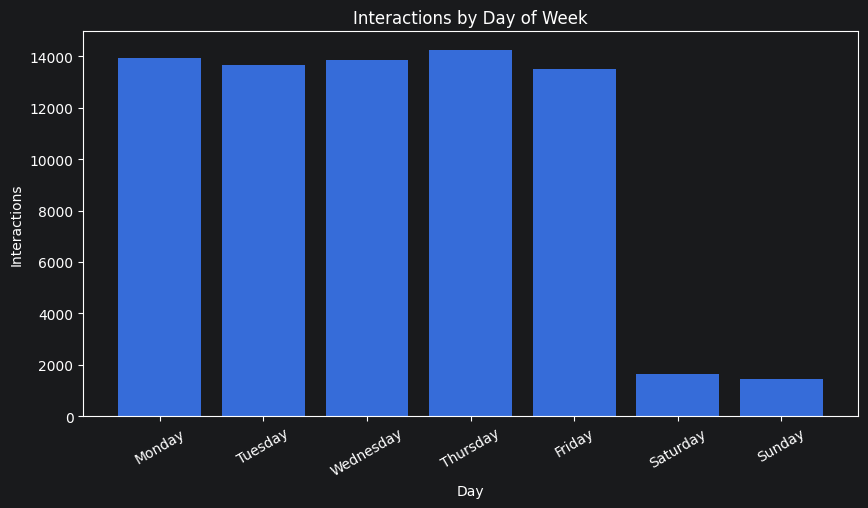

In [37]:
consumer["day_of_week"] = (consumer["event_datetime"].dt.day_name())
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_stats = (consumer["day_of_week"].value_counts().reindex(weekday_order))
plt.figure(figsize=(10, 5))
plt.bar(weekday_stats.index,weekday_stats.values)
plt.xticks(rotation=30)
plt.xlabel("Day")
plt.ylabel("Interactions")
plt.title("Interactions by Day of Week")
plt.show()

## 16. Interaction Type * Time

- Calculate daily volume for each interaction type.
- Supports interaction-weight design For example, later test whether: save/comment are stronger indicators of future engagement than merely: watch

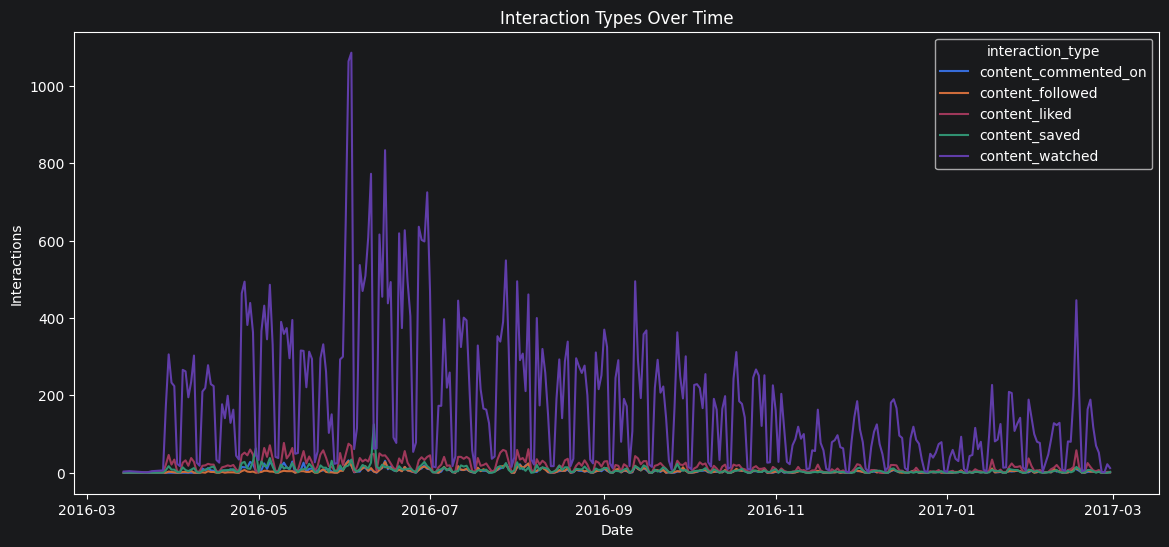

In [38]:
interaction_time = (consumer.groupby([consumer["event_datetime"].dt.date,"interaction_type"]).size().unstack(fill_value=0))
interaction_time.plot(figsize=(14, 6))
plt.xlabel("Date")
plt.ylabel("Interactions")
plt.title("Interaction Types Over Time")
plt.show()

## 17. Session Level Analysis

- Aggregate interaction events at the user-session level.
- Long-term profile: User usually likes sports.
- Current session: User is currently reading AI articles.
- Both signals can be useful for ranking.

In [40]:
session_stats = (consumer.groupby(["consumer_id","consumer_session_id"]).agg(
    session_events=("item_id", "size"),unique_articles=("item_id", "nunique"),
    session_start=("event_datetime", "min"),session_end=("event_datetime", "max")))
session_stats["session_duration_minutes"] = ((session_stats["session_end"] -
session_stats["session_start"]).dt.total_seconds() / 60)
display(session_stats[["session_events","unique_articles","session_duration_minutes"]].describe(percentiles=[.50,.75,.90,.95,.99]))

,session_events,unique_articles,session_duration_minutes
count,28909.000000,28909.000000,28909.000000
mean,2.501366,1.600678,78.900725
std,3.205310,1.502388,198.358360
min,1.000000,1.000000,0.000000
50%,2.000000,1.000000,0.000000
75%,3.000000,2.000000,16.983333
90%,5.000000,3.000000,311.703333
95%,7.000000,4.000000,479.773333
99%,15.000000,8.000000,1082.783333
max,182.000000,42.000000,1431.033333


## 18. Session Depth

- If sessions contain meaningful numbers of sequential interactions, have evidence for implementing session-aware recommendation.

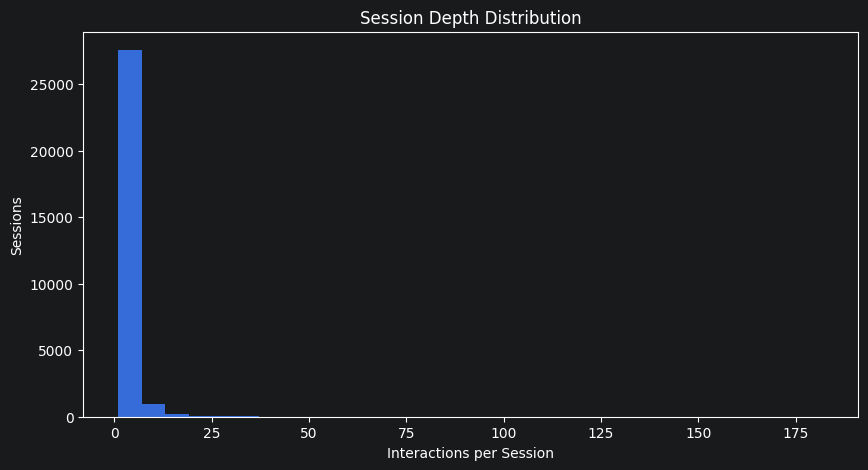

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(session_stats["session_events"], bins=30)
plt.xlabel("Interactions per Session")
plt.ylabel("Sessions")
plt.title("Session Depth Distribution")
plt.show()

## 19. Consumer Article Repeat Behavior

- Count how many events each user generated for each article.
- Directly informs: ALS confidence weights

In [42]:
# ============================================================
# Repeat Interaction Analysis
# ============================================================
user_item_counts = (consumer.groupby(["consumer_id","item_id"]).size().reset_index(name="interaction_count"))

print("User-item pairs with >1 interaction:",(user_item_counts["interaction_count"] > 1).sum())

print("Percentage:",round((user_item_counts["interaction_count"] > 1).mean() * 100,2),"%")

User-item pairs with >1 interaction: 16640
Percentage: 40.87 %


## 20. Platfrom Content

- Inspect the article catalog structure.
- Dataset supplies the content information required for content-based and semantic recommendation.

In [43]:
print("Shape:", content.shape)
print("Columns:")
print(content.columns.tolist())
print("Data Types:")
display(content.dtypes)
print("Unique Values:")
display(content.nunique())

Shape: (3122, 14)
Columns:
['event_timestamp', 'interaction_type', 'item_id', 'producer_id', 'producer_session_id', 'producer_device_info', 'producer_location', 'producer_country', 'item_type', 'item_url', 'title', 'text_description', 'language', 'event_datetime']
Data Types:


event_timestamp                       int64
interaction_type                     object
item_id                               int64
producer_id                           int64
producer_session_id                   int64
producer_device_info                 object
producer_location                    object
producer_country                     object
item_type                            object
item_url                             object
title                                object
text_description                     object
language                             object
event_datetime          datetime64[ns, UTC]
dtype: object

Unique Values:


event_timestamp         3121
interaction_type           2
item_id                 3057
producer_id              252
producer_session_id     2017
producer_device_info     114
producer_location         19
producer_country           5
item_type                  3
item_url                3029
title                   3011
text_description        3019
language                   5
event_datetime          3121
dtype: int64

## 21. Content Lifecycle Analysis

-  Identify how many records represent: content_present, content_pulled_out
- final recommender must implement: Candidate Generation -> Availability Filter -> Remove pulled-out articles -> Ranking

interaction_type
content_present       3047
content_pulled_out      75
Name: count, dtype: int64

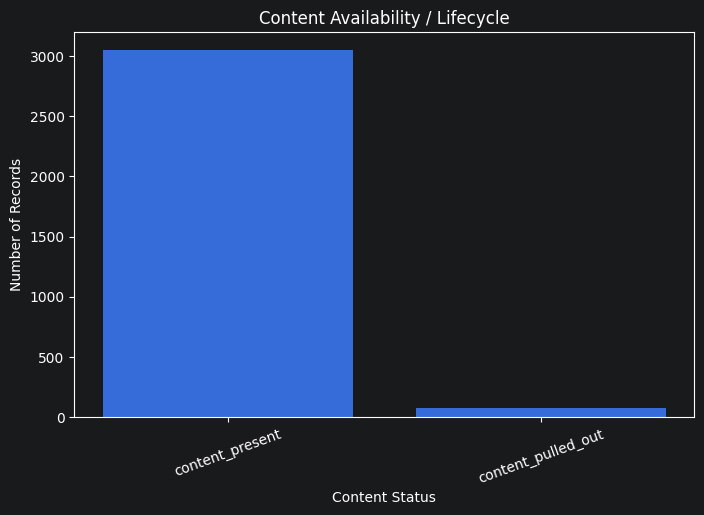

In [44]:
content_status = (content["interaction_type"].value_counts())
display(content_status)
plt.figure(figsize=(8, 5))
plt.bar(content_status.index,content_status.values)
plt.xlabel("Content Status")
plt.ylabel("Number of Records")
plt.title("Content Availability / Lifecycle")
plt.xticks(rotation=20)
plt.show()

## 22. Article Type Analysis

- Analyze the distribution of: HTML, Video, Rich
- Content type can affect engagement behavior and therefore can become a ranking feature.

item_type
HTML     3101
VIDEO      11
RICH       10
Name: count, dtype: int64

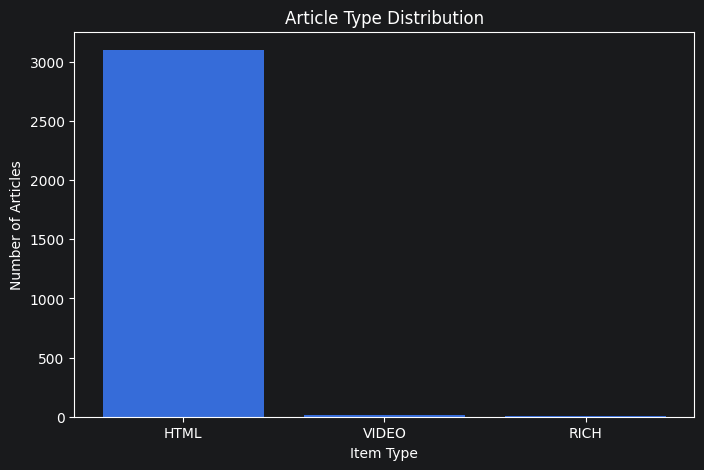

In [45]:
item_type_stats = (content["item_type"].value_counts())
display(item_type_stats)
plt.figure(figsize=(8, 5))
plt.bar(item_type_stats.index, item_type_stats.values)
plt.xlabel("Item Type")
plt.ylabel("Number of Articles")
plt.title("Article Type Distribution")
plt.show()

## 23. Language Analysis

- Analyze content language distribution.
- Project requirement specifies that content-based  recommendation should consider English content.

language
en    2264
pt     850
la       4
es       2
ja       2
Name: count, dtype: int64

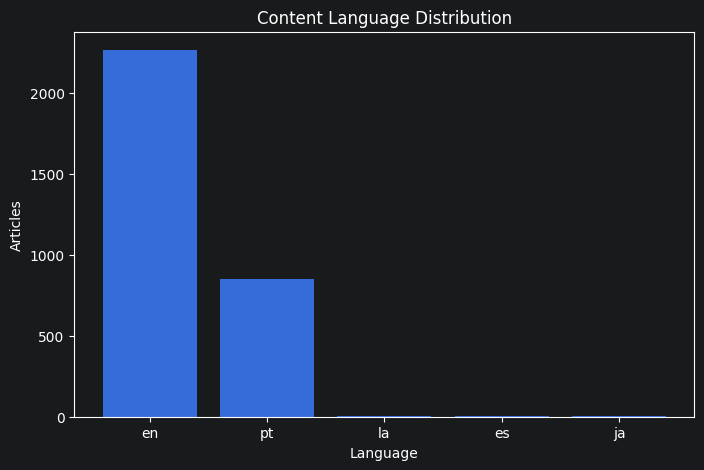

In [46]:
language_stats = (content["language"].value_counts(dropna=False))
display(language_stats)
plt.figure(figsize=(8, 5))
plt.bar(language_stats.index.astype(str),language_stats.values)
plt.xlabel("Language")
plt.ylabel("Articles")
plt.title("Content Language Distribution")
plt.show()

## 24. English Content Availabilty

- Restrict content-based recommendation candidates to English.
- This implements the explicit business requirement.

In [47]:
english_content = content[content["language"].eq("en")].copy()
print("English articles:",len(english_content))
print("English percentage:", round(len(english_content) / len(content) * 100, 2))

English articles: 2264
English percentage: 72.52


## 25. Title And Desciption Quality

- Calculate number of words in each article title.
- Calculate number of words in each article description.
- Before using: TF-IDF, Sentence Transformers
- Know whether article text is: missing, too short, duplicate, usable

In [48]:
content["title_length"] = (content["title"].fillna("").str.split().str.len())
content["description_length"] = (content["text_description"].fillna("").str.split().str.len())
display(content[["title_length","description_length"]].describe(percentiles=[.50,.75,.90,.95,.99]))

,title_length,description_length
count,3122.000000,3122.000000
mean,9.337284,899.983985
std,3.716217,1046.109395
min,1.000000,43.000000
50%,9.000000,609.000000
75%,12.000000,1128.000000
90%,14.000000,1873.800000
95%,16.000000,2621.950000
99%,19.000000,4955.640000
max,29.000000,19154.000000


In [49]:
print("Titles with <= 3 words:",(content["title_length"] <= 3).sum())
print("Descriptions with <= 50 words:",(content["description_length"] <= 50).sum())

Titles with <= 3 words: 188
Descriptions with <= 50 words: 37


## 26. Content Duplicate Analysis

- Duplicate titles can indicate: syndicated articles, duplicate ingestion, multiple versions of the same story

In [50]:
print("Duplicate titles:", content["title"].duplicated().sum())
print("Duplicate descriptions:", content["text_description"].duplicated().sum())
print("Duplicate URLs:", content["item_url"].duplicated().sum())

Duplicate titles: 111
Duplicate descriptions: 103
Duplicate URLs: 93


In [51]:
duplicate_titles = (content[content["title"].duplicated(keep=False)].sort_values("title"))
display(duplicate_titles[["item_id","title","language","item_type"]].head(20))

,item_id,title,language,item_type
1908,7251252752220327534,9 Non-Threatening Leadership Strategies for Women,en,HTML
1909,7251252752220327534,9 Non-Threatening Leadership Strategies for Women,en,HTML
1910,1881534532776527237,9 Non-Threatening Leadership Strategies for Women,en,HTML
683,-456574518348806233,A Single App That'll Wrangle Your Millions of ...,en,HTML
682,-4187268503708157132,A Single App That'll Wrangle Your Millions of ...,en,HTML
681,-4187268503708157132,A Single App That'll Wrangle Your Millions of ...,en,HTML
684,-456574518348806233,A Single App That'll Wrangle Your Millions of ...,en,HTML
1513,-7568926158048616650,Adobe CQ/Adobe AEM,en,HTML
2269,-6902744509271060072,Adobe CQ/Adobe AEM,en,HTML
1515,-8632408281960398473,Adobe CQ/Adobe AEM,en,HTML


## 27. Producer Analysis

- Analyze how much content each producer contributes.
- later support:  producer popularity, producer affinity, producer CTR, user-producer preference

In [52]:
producer_stats = (content.groupby("producer_id").agg(articles=("item_id", "nunique"),countries=("producer_country", "nunique"),locations=("producer_location", "nunique")).sort_values("articles",ascending=False))
display(producer_stats.head(20))

,articles,countries,locations
producer_id,,,
3609194402293569455,304,1,1
-1443636648652872475,296,1,1
-1032019229384696495,267,2,2
3891637997717104548,132,1,1
-2979881261169775358,89,0,0
-709287718034731589,78,1,1
4340306774493623681,74,0,0
-8020832670974472349,67,1,1
3217014177234377440,62,1,1


## 28. Consumer + Content Join Coverage

- Compare article IDs appearing in: consumer interaction logs,  platform content catalog
- This verifies whether interaction records can be enriched  with article metadata.
- If an interacted article isn't present in the content catalog cannot obtain title, description, language, item_type, producer

In [54]:
consumer_items = set(consumer["item_id"].unique())
content_items = set(content["item_id"].unique())
common_items = (consumer_items & content_items)
consumer_only_items = (consumer_items - content_items)
content_only_items = (content_items - consumer_items)
print("Consumer interaction items:", len(consumer_items))
print("Content catalog items:", len(content_items))
print("Common items:", len(common_items))
print("Consumer-only items:", len(consumer_only_items))
print("Content-only items:", len(content_only_items))

Consumer interaction items: 2987
Content catalog items: 3057
Common items: 2987
Consumer-only items: 0
Content-only items: 70


In [55]:
consumer_join_coverage = (consumer["item_id"].isin(content_items).mean())
print(f"Interaction row coverage: " f"{consumer_join_coverage:.2%}")

Interaction row coverage: 100.00%


## 29. Create Master Analytical Tables

- Select article-level metadata required for recommendation.

In [56]:
content_features = content[["item_id", "producer_id", "item_type", "title", "text_description","language", "item_url", "producer_country", "producer_location"]].drop_duplicates(subset=["item_id"])
master = consumer.merge(content_features,on="item_id", how="left", suffixes=("_consumer", "_content"))
print("Master shape:", master.shape)
display(master.head())

Master shape: (72312, 19)


,event_timestamp,interaction_type,item_id,consumer_id,consumer_session_id,consumer_device_info,consumer_location,country,event_datetime,hour,day_of_week,producer_id,item_type,title,text_description,language,item_url,producer_country,producer_location
0,1465413032,content_watched,-3499919498720038879,-8845298781299428018,1264196770339959068,NaN,NaN,NaN,2016-06-08 19:10:32+00:00,19,Wednesday,-1032019229384696495,HTML,Hiri wants to fix the workplace email problem,Hiri is the latest startup trying to fix email...,en,http://techcrunch.com/2016/06/07/hiri/,NaN,NaN
1,1465412560,content_watched,8890720798209849691,-1032019229384696495,3621737643587579081,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,NY,US,2016-06-08 19:02:40+00:00,19,Wednesday,1895326251577378793,HTML,Top 10 Intranet Trends of 2016,"Summary: Hero images, carousels, fat footers, ...",en,https://www.nngroup.com/articles/top-intranet-...,NaN,NaN
2,1465416190,content_watched,310515487419366995,-1130272294246983140,2631864456530402479,NaN,NaN,NaN,2016-06-08 20:03:10+00:00,20,Wednesday,-5527145562136413747,HTML,71 erros de português que precisam sumir dos s...,Escrever um e-mail não deveria ser uma coisa t...,pt,http://blog.runrun.it/erros-de-portugues-em-e-...,NaN,NaN
3,1465413895,content_followed,310515487419366995,344280948527967603,-3167637573980064150,NaN,NaN,NaN,2016-06-08 19:24:55+00:00,19,Wednesday,-5527145562136413747,HTML,71 erros de português que precisam sumir dos s...,Escrever um e-mail não deveria ser uma coisa t...,pt,http://blog.runrun.it/erros-de-portugues-em-e-...,NaN,NaN
4,1465412290,content_watched,-7820640624231356730,-445337111692715325,561148 1178424124714,NaN,NaN,NaN,2016-06-08 18:58:10+00:00,18,Wednesday,-1032019229384696495,HTML,How This Googler Redesigned The Workweek,Jake Knapp has always been concerned about the...,en,http://www.fastcompany.com/3058876/your-most-p...,NaN,NaN


## 30. Interaction * Content Type

- Analyze whether users behave differently toward HTML, Video, Rich this can becomes a contextual ranking features
- ranking model can learn : user * content_type preferences

item_type,HTML,RICH,VIDEO
interaction_type,,,
content_commented_on,99.38,0.12,0.50
content_followed,99.50,0.14,0.36
content_liked,99.62,0.09,0.30
content_saved,99.55,0.20,0.24
content_watched,99.54,0.17,0.29


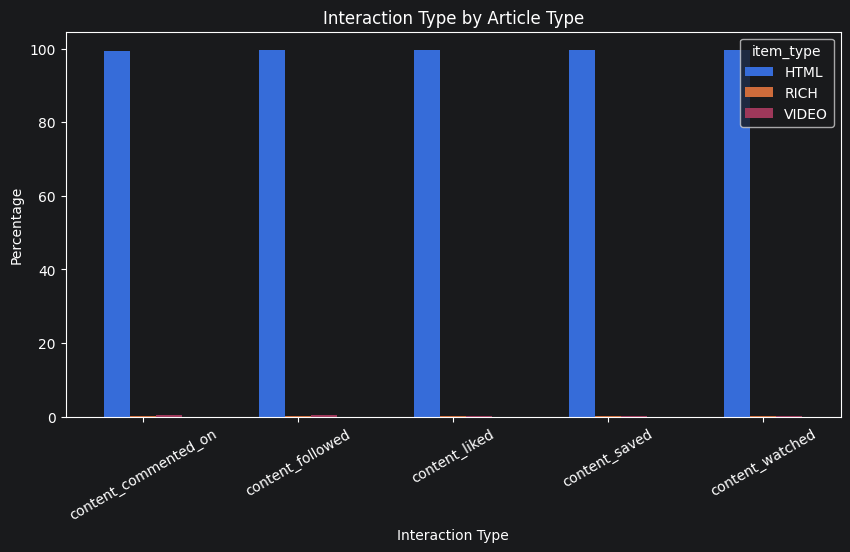

In [57]:
interaction_item_type = pd.crosstab(master["interaction_type"],master["item_type"],normalize="index") * 100
display(interaction_item_type.round(2))
interaction_item_type.plot(kind="bar",figsize=(10, 5))
plt.xlabel("Interaction Type")
plt.ylabel("Percentage")
plt.title("Interaction Type by Article Type")
plt.xticks(rotation=30)
plt.show()

## 31. Interaction * Language

-  Analyze engagement behavior by content language.
- Useful for validating the English-content business rule and understanding language-specific engagement.

In [58]:
interaction_language = pd.crosstab(master["interaction_type"],master["language"],normalize="index") * 100
display(interaction_language.round(2))

language,en,es,ja,la,pt
interaction_type,,,,,
content_commented_on,64.43,0.00,0.00,0.19,35.38
content_followed,64.11,0.00,0.00,0.21,35.68
content_liked,59.72,0.02,0.05,0.14,40.07
content_saved,74.99,0.00,0.00,0.04,24.97
content_watched,65.23,0.01,0.05,0.06,34.64


## 32. User Category / Topic Affinity After Deriving Topics

- TF-IDF gives you an interpretable baseline.
- keep it even after implementing SBERT.
- model comparison becomes: Popularity -> TF-IDF -> ALS -> Semantic Embedding -> Hybrid-> Learning-to-Rank

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Restrict semantic/content processing to English articles.
english_content = content[content["language"].eq("en")].copy()

# Combine title and description into one textual representation.
# 1. Title provides strong topical keywords.
# 2. Description provides additional semantic context.
english_content["article_text"] = (english_content["title"].fillna("") + " " +english_content["text_description"].fillna(""))

# TF-IDF converts article text into sparse numerical vectors.
# max_features:
#     Limits vocabulary size to control memory/computation.
# stop_words:
#     Removes common English words.
# ngram_range=(1,2):
#     Captures both individual words and two-word phrases.
# min_df=2:
#     Removes terms appearing in only one document.
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2), min_df=2)

# Transform article text into sparse TF-IDF vectors.
tfidf_matrix = vectorizer.fit_transform(english_content["article_text"])
print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (2264, 10000)


## 33. Topics Clustering

- dataset doesn't have an explicit: category, genre, topic column thefore can derive latent topic representation

In [61]:
from sklearn.cluster import MiniBatchKMeans
n_topics = 15
kmeans = MiniBatchKMeans(n_clusters=n_topics, random_state=42, batch_size=256, n_init="auto")
english_content["topic_id"] = (kmeans.fit_predict(tfidf_matrix))
print(english_content["topic_id"].value_counts().sort_index());

topic_id
0       15
1      167
2       17
3      176
4     1184
5      123
6      113
7       93
8       47
9       54
10      95
11      19
12      29
13      55
14      77
Name: count, dtype: int64


## 34. Topic Interpretation

- Verify that your clusters actually resemble meaningful themes rather than random groups.

In [64]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for topic_id in range(n_topics):
    top_terms = [terms[i]for i in order_centroids[topic_id, :10]]
    print(f"Topic {topic_id}:", " , ".join(top_terms))

Topic 0: trend , brands , trends , innovations , business , big brands , trendwatching , business model , briefing , expectations
Topic 1: google , android , apps , app , new , vr , google apps , google play , cloud , search
Topic 2: data , data science , science , data scientists , scientists , airbnb , team , engineers , new , science team
Topic 3: digital , bank , customer , mobile , banking , banks , customers , business , companies , new
Topic 4: code , time , like , new , people , data , use , app , just , work
Topic 5: cloud , docker , google , container , google cloud , kubernetes , gcp , containers , cloud platform , aws
Topic 6: learning , machine learning , machine , deep learning , google , deep , neural , data , intelligence , tensorflow
Topic 7: bot , bots , usa , technical specs , specs , credits , chatbots , technical , messenger , facebook
Topic 8: data , analytics , machine , machine learning , learning , python , scikit , models , model , scikit learn
Topic 9: drupal

## 35. Topics Popularity

- this supports topic popularity + user topic affinity + topic novelty + topic diversity

In [65]:
master_topics = master.merge(english_content[["item_id","topic_id"]],on="item_id",how="left")
topic_popularity = (master_topics.groupby("topic_id").agg(interactions=("consumer_id", "size"),
                                                          unique_users=("consumer_id", "nunique"),unique_articles=("item_id", "nunique")).sort_values("interactions",ascending=False))
display(topic_popularity)

,interactions,unique_users,unique_articles
topic_id,,,
4.0,26994,1472,1127
3.0,3922,489,168
1.0,3766,580,162
5.0,2719,469,122
6.0,2004,271,107
14.0,1191,301,74
7.0,1180,252,79
9.0,1021,189,54
12.0,991,234,28


## 36. Popularity Bias VS Personalization

- answers a critical business question: Are users engaging because an article is globally popular, or because it is personally relevant?

In [66]:
user_item = (consumer.groupby(["consumer_id", "item_id"]).size().reset_index(name="interaction_count"))
article_popularity = (consumer.groupby("item_id").size().reset_index(name="article_interactions"))
user_item = user_item.merge(article_popularity,on="item_id")
display(user_item[["interaction_count","article_interactions"]].describe())

,interaction_count,article_interactions
count,40710.000000,40710.000000
mean,1.776271,62.400270
std,1.690431,68.208183
min,1.000000,1.000000
25%,1.000000,19.000000
50%,1.000000,39.000000
75%,2.000000,78.000000
max,96.000000,433.000000


## 37. Summary Recommendation EDA

In [67]:
eda_summary = {"num_users": consumer["consumer_id"].nunique(),"num_articles": consumer["item_id"].nunique(),"num_sessions": consumer["consumer_session_id"].nunique(),"num_interactions": len(consumer),"interaction_types":consumer["interaction_type"].nunique(),
"english_articles": content["language"].eq("en").sum(),"pulled_articles":content["interaction_type"].eq("content_pulled_out").sum(),"repeat_user_item_pairs":user_item_duplicates,"user_item_sparsity":sparsity}
eda_summary

{'num_users': 1895,
 'num_articles': 2987,
 'num_sessions': 28909,
 'num_interactions': 72312,
 'interaction_types': 5,
 'english_articles': 2264,
 'pulled_articles': 75,
 'repeat_user_item_pairs': 31602,
 'user_item_sparsity': 0.992807884297214}

## Saved Cleaned Consumer Data

In [88]:
from pathlib import Path

# ------------------------------------------------------------
# Create reusable artifact directories
# ------------------------------------------------------------

ARTIFACT_DIR = Path("../artifacts")
PROCESSED_DIR = ARTIFACT_DIR / "processed"
EDA_DIR = ARTIFACT_DIR / "eda"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Save cleaned consumer interaction dataset
# ------------------------------------------------------------

consumer_clean = consumer.copy()

# Ensure session IDs are unified as strings to prevent ArrowTypeError
consumer_clean["consumer_session_id"] = consumer_clean["consumer_session_id"].astype(str)

consumer_clean.to_parquet(
    PROCESSED_DIR / "consumer_clean.parquet",
    index=False
)

print("Saved:", PROCESSED_DIR / "consumer_clean.parquet")

Saved: ..\artifacts\processed\consumer_clean.parquet


## Save Cleaned Content Data

In [89]:
# ------------------------------------------------------------
# Save cleaned platform content dataset
# ------------------------------------------------------------
content_clean = content.copy()
content_clean.to_parquet(PROCESSED_DIR / "content_clean.parquet",index=False)
print("Saved:", PROCESSED_DIR / "content_clean.parquet")

Saved: ..\artifacts\processed\content_clean.parquet


## Save master dataset

In [91]:
# ------------------------------------------------------------
# Build reusable master interaction table
# ------------------------------------------------------------

content_features = content[
    ["item_id","producer_id","item_type","title","text_description", "language","item_url","producer_country","producer_location"]
].drop_duplicates(subset=["item_id"])

# Fix mixed types in consumer_session_id before merging
consumer_clean = consumer.copy()
consumer_clean["consumer_session_id"] = consumer_clean["consumer_session_id"].astype(str)

master = consumer_clean.merge(content_features, on="item_id", how="left", suffixes=("_consumer","_content"))

# Save for downstream feature engineering.
master.to_parquet(PROCESSED_DIR / "master_interactions.parquet", index=False)
print("Saved:", PROCESSED_DIR / "master_interactions.parquet")

Saved: ..\artifacts\processed\master_interactions.parquet


## Save EDA Summary

In [92]:
import json
eda_summary = {"num_users": int(consumer["consumer_id"].nunique()),
    "num_articles": int(consumer["item_id"].nunique()),
    "num_sessions": int(consumer["consumer_session_id"].nunique()),
    "num_interactions": int(
        len(consumer)
    ),

    "num_interaction_types": int(
        consumer["interaction_type"].nunique()
    ),

    "num_english_articles": int(
        content["language"]
        .eq("en")
        .sum()
    ),

    "num_pulled_articles": int(
        content[
            "interaction_type"
        ]
        .eq("content_pulled_out")
        .sum()
    ),

    "user_item_sparsity": float(
        sparsity
    ),

    "repeat_user_item_rows": int(
        user_item_duplicates
    ),

    "item_join_coverage": float(
        consumer["item_id"]
        .isin(content["item_id"])
        .mean()
    )
}


with open(
    EDA_DIR / "eda_summary.json",
    "w"
) as f:

    json.dump(
        eda_summary,
        f,
        indent=4
    )

## Save Important EDA Tables

In [93]:
user_activity.to_csv(
    EDA_DIR / "user_activity.csv"
)

In [94]:
article_popularity.to_csv(
    EDA_DIR / "article_popularity.csv"
)

In [95]:
session_stats.to_csv(
    EDA_DIR / "session_statistics.csv"
)

In [96]:
language_stats.to_csv(
    EDA_DIR / "language_distribution.csv"
)

In [97]:
interaction_stats = (
    consumer["interaction_type"]
    .value_counts()
)

interaction_stats.to_csv(
    EDA_DIR / "interaction_distribution.csv"
)

## Save Important Plots

In [98]:
PLOT_DIR = EDA_DIR / "plots"

PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

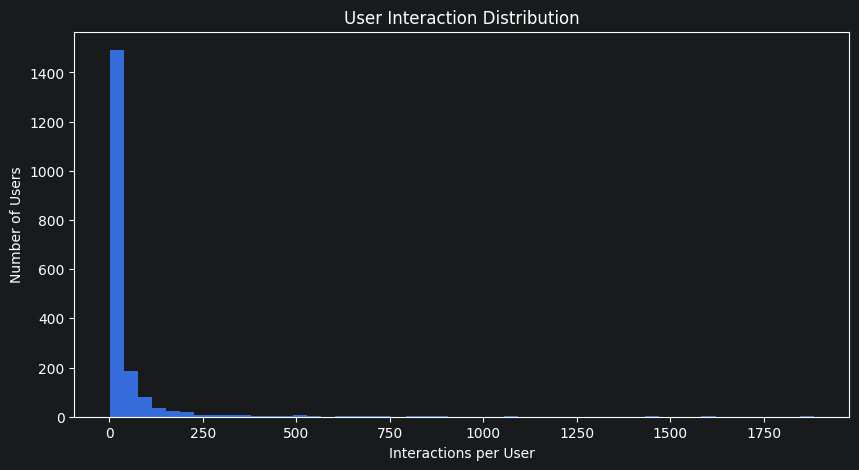

In [99]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_activity["total_interactions"],
    bins=50
)

plt.xlabel("Interactions per User")
plt.ylabel("Number of Users")
plt.title("User Interaction Distribution")

plt.savefig(
    PLOT_DIR / "user_interaction_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Save DATA DICTIONARY + Decisions